<a href="https://colab.research.google.com/github/muhsina419/Machine_learning_-_Parallel_computing_s6/blob/main/Q12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyclustering scikit-fuzzy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 56.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 43.3 MB/s eta 0:00:00
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=b4402d1c3088485e48b9b653692a43f0418e0a66bc2466a47a85e51e4c7bb75c
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


Silhouette Scores:
K-Means: 0.551
K-Medoids: 0.555
Fuzzy C-Means: 0.550


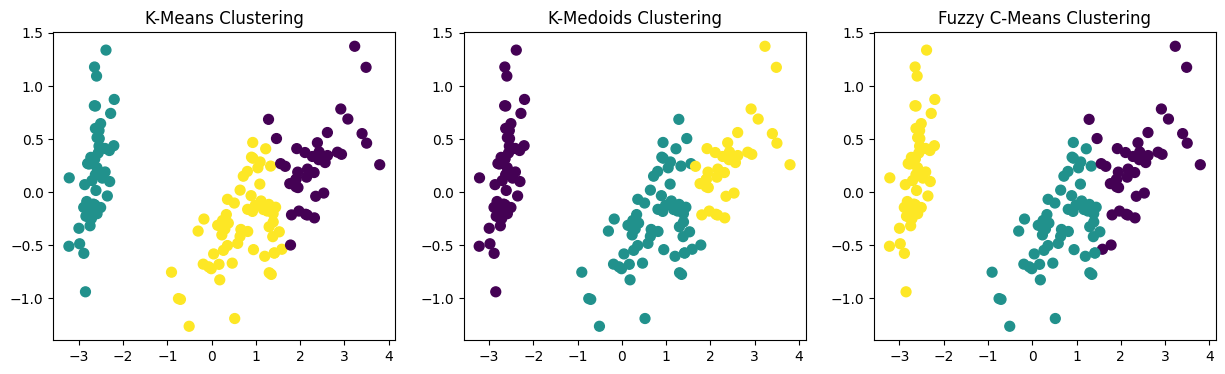

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
# K-Medoids via pyclustering
from pyclustering.cluster.kmedoids import kmedoids
# Fuzzy C-Means
import skfuzzy as fuzz
iris = load_iris()
X = iris.data
y = iris.target
n_clusters = 3
# ------------------- K-Means -------------------
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(X)
silhouette_kmeans = silhouette_score(X, labels_kmeans)
# ------------------- K-Medoids -------------------
# Initial medoid indices
initial_medoids = [0, 50, 100]
kmedoids_instance = kmedoids(X, initial_medoids)
kmedoids_instance.process()
clusters = kmedoids_instance.get_clusters()
# Convert cluster lists to flat label array
labels_kmedoids = np.zeros(X.shape[0])
for cluster_id, cluster_points in enumerate(clusters):
    for idx in cluster_points:
        labels_kmedoids[idx] = cluster_id
silhouette_kmedoids = silhouette_score(X, labels_kmedoids)
# ------------------- Fuzzy C-Means -------------------
X_T = X.T  # skfuzzy expects features x samples
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_T, c=n_clusters, m=2, error=0.005, maxiter=1000)
labels_fcm = np.argmax(u, axis=0)
silhouette_fcm = silhouette_score(X, labels_fcm)
print("Silhouette Scores:")
print(f"K-Means: {silhouette_kmeans:.3f}")
print(f"K-Medoids: {silhouette_kmedoids:.3f}")
print(f"Fuzzy C-Means: {silhouette_fcm:.3f}")
X_2D = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.scatter(X_2D[:,0], X_2D[:,1], c=labels_kmeans, cmap='viridis', s=50)
plt.title('K-Means Clustering')
plt.subplot(1,3,2)
plt.scatter(X_2D[:,0], X_2D[:,1], c=labels_kmedoids, cmap='viridis', s=50)
plt.title('K-Medoids Clustering')
plt.subplot(1,3,3)
plt.scatter(X_2D[:,0], X_2D[:,1], c=labels_fcm, cmap='viridis', s=50)
plt.title('Fuzzy C-Means Clustering')
plt.show()